# Sentiment Classification on IMDB Movie Reviews

This notebook builds and compares multiple sentiment classification models on the IMDB movie review dataset:

1. Load & explore the dataset
2. Preprocess text (cleaning, tokenization, stopword removal, lemmatization)
3. Baseline sentiment via **TextBlob**
4. Vectorize text using **TF-IDF**
5. Train **Naive Bayes**, **SVM (LinearSVC)**, and **Random Forest**
6. Evaluate with **Accuracy, Precision, Recall, F1-score**
7. Visualize model comparison and confusion matrices


In [1]:
import re
import string
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from textblob import TextBlob

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    try:
        nltk.data.find(f"tokenizers/{pkg}" if "punkt" in pkg else f"corpora/{pkg}")
    except LookupError:
        nltk.download(pkg, quiet=True)

STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()
RANDOM_STATE = 42


## 1. Load the dataset

In [2]:
df = pd.read_csv("IMDB_Dataset.csv")
df = df.dropna(subset=["review", "sentiment"]).drop_duplicates(subset=["review"])
print(df.shape)
df.head()


(49582, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


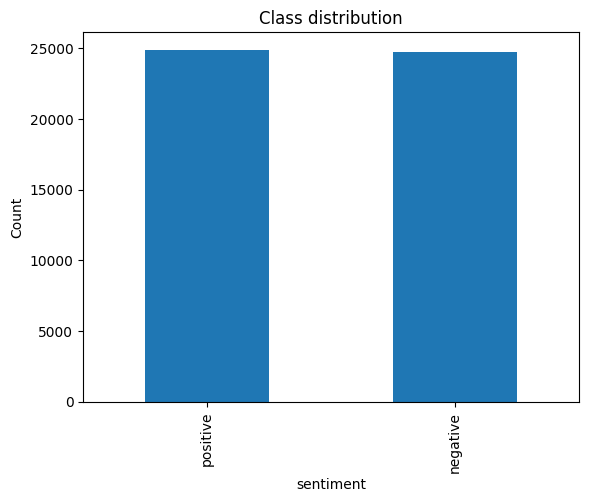

In [3]:
df["sentiment"].value_counts().plot(kind="bar", title="Class distribution")
plt.ylabel("Count")
plt.show()


## 2. Preprocess text

We sample a subset of the full 50,000-review dataset to keep training fast for this exercise. Set `SAMPLE_SIZE = None` to use the full dataset.

In [4]:
SAMPLE_SIZE = 8000

if SAMPLE_SIZE is not None and len(df) > SAMPLE_SIZE:
    per_class = SAMPLE_SIZE // 2
    parts = [g.sample(per_class, random_state=RANDOM_STATE) for _, g in df.groupby("sentiment")]
    df = pd.concat(parts).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})
print(df["label"].value_counts())


label
0    4000
1    4000
Name: count, dtype: int64


In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess(text):
    cleaned = clean_text(text)
    tokens = word_tokenize(cleaned)
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens if t not in STOP_WORDS and len(t) > 2]
    return " ".join(tokens)

df["clean_review"] = df["review"].apply(preprocess)
df[["review", "clean_review"]].head()


,review,clean_review
0,Sorry for any spoilers that this contains. But...,sorry spoiler contains want read anyway really...
1,"First of all, just let me say this... Ghost St...",first let say ghost storyhello people trashed ...
2,"I've never been a huge fan of Almodovar, but, ...",ive never huge fan almodovar generally ive alw...
3,This movie was very very mediocre and very ver...,movie mediocre gory everyone left acting lesso...
4,yes i have a copy of it on VHS uncut in great ...,yes copy vhs uncut great condition transfered ...


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_review"], df["label"], test_size=0.2, random_state=RANDOM_STATE, stratify=df["label"]
)
print(len(X_train), len(X_test))


6400 1600


## 3. Baseline: TextBlob polarity

In [7]:
def textblob_predict(text):
    polarity = TextBlob(text).sentiment.polarity
    return 1 if polarity >= 0 else 0

tb_preds = X_test.apply(textblob_predict)


## 4. TF-IDF vectorization

In [8]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
X_train_tfidf.shape


(6400, 5000)

## 5. Train models: Naive Bayes, SVM, Random Forest

In [9]:
models = {
    "Naive Bayes": MultinomialNB(),
    "SVM (LinearSVC)": LinearSVC(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
}

predictions = {"TextBlob (baseline)": tb_preds}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    predictions[name] = model.predict(X_test_tfidf)
    print(f"Trained: {name}")


Trained: Naive Bayes
Trained: SVM (LinearSVC)


Trained: Random Forest


## 6. Evaluate: Accuracy, Precision, Recall, F1-score

In [10]:
results = []
reports = {}
for name, preds in predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds),
    })
    reports[name] = classification_report(y_test, preds, target_names=["negative", "positive"])

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df


,Accuracy,Precision,Recall,F1-Score
Model,,,,
TextBlob (baseline),0.7019,0.6391,0.9275,0.7568
Naive Bayes,0.8669,0.8601,0.8762,0.8681
SVM (LinearSVC),0.8462,0.8489,0.8425,0.8457
Random Forest,0.8375,0.8409,0.8325,0.8367


In [11]:
print(reports["Naive Bayes"])


              precision    recall  f1-score   support

    negative       0.87      0.86      0.87       800
    positive       0.86      0.88      0.87       800

    accuracy                           0.87      1600
   macro avg       0.87      0.87      0.87      1600
weighted avg       0.87      0.87      0.87      1600



## 7. Visualizations

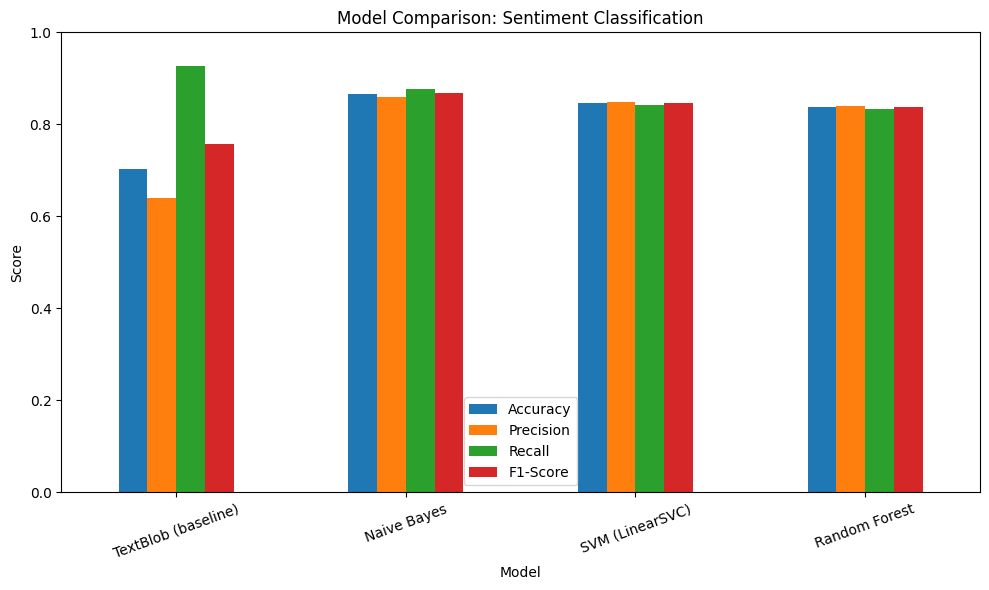

In [12]:
ax = results_df.plot(kind="bar", figsize=(10, 6), rot=20)
ax.set_title("Model Comparison: Sentiment Classification")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


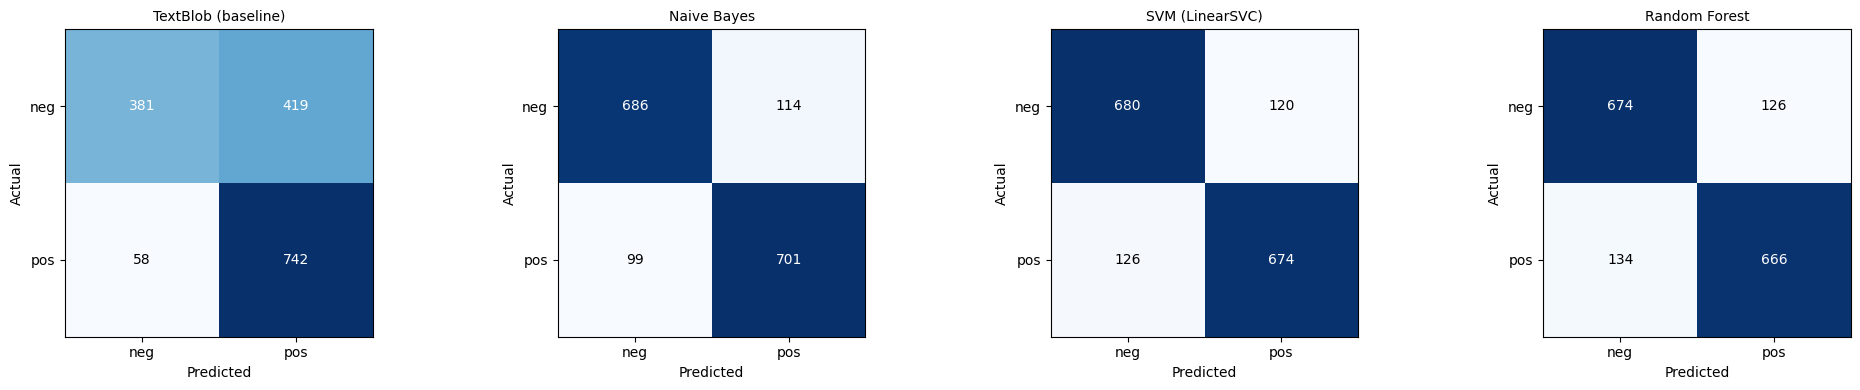

In [13]:
fig, axes = plt.subplots(1, len(predictions), figsize=(5 * len(predictions), 4))
for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds)
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["neg", "pos"]); ax.set_yticklabels(["neg", "pos"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout()
plt.show()


## Conclusion

- **TextBlob** (rule-based, untrained) provides a quick baseline but underperforms trained models.
- **Naive Bayes** on TF-IDF features is fast and gives strong performance for this task.
- **SVM (LinearSVC)** typically performs comparably to or better than Naive Bayes on text classification.
- **Random Forest** is more computationally expensive and doesn't always outperform simpler linear models on sparse high-dimensional TF-IDF features.
